In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("data/sales.csv")

In [5]:
df.head(5)

,Order_ID,Order_Date,Customer_Name,Product,Category,Region,Quantity,Unit_Price,Sales,Profit
0,1001,2025-01-05,Aman,Laptop,Electronics,West,1,55000,55000,7000
1,1002,2025-01-08,Rahul,Mouse,Electronics,North,3,800,2400,600
2,1003,2025-01-12,Priya,Keyboard,Electronics,South,2,1500,3000,700
3,1004,2025-01-15,Neha,Chair,Furniture,West,2,4500,9000,1800
4,1005,2025-01-20,Ali,Desk,Furniture,North,1,8000,8000,1500


In [7]:
df.shape

(20, 10)

In [8]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Product', 'Category',
       'Region', 'Quantity', 'Unit_Price', 'Sales', 'Profit'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Order_ID       20 non-null     int64
 1   Order_Date     20 non-null     str  
 2   Customer_Name  20 non-null     str  
 3   Product        20 non-null     str  
 4   Category       20 non-null     str  
 5   Region         20 non-null     str  
 6   Quantity       20 non-null     int64
 7   Unit_Price     20 non-null     int64
 8   Sales          20 non-null     int64
 9   Profit         20 non-null     int64
dtypes: int64(5), str(5)
memory usage: 1.7 KB


In [10]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_Name    0
Product          0
Category         0
Region           0
Quantity         0
Unit_Price       0
Sales            0
Profit           0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Order_ID,Quantity,Unit_Price,Sales,Profit
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,1010.50000,2.300000,15645.000000,22760.000000,3435.000000
std,5.91608,1.380313,20511.677675,26747.304832,3230.166201
min,1001.00000,1.000000,800.000000,2400.000000,600.000000
25%,1005.75000,1.000000,3750.000000,6450.000000,1200.000000
50%,1010.50000,2.000000,7500.000000,13750.000000,2550.000000
75%,1015.25000,3.000000,12000.000000,24000.000000,4000.000000
max,1020.00000,6.000000,55000.000000,110000.000000,14000.000000


In [14]:
df["Order_Date"]=pd.to_datetime(df["Order_Date"])

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       20 non-null     int64         
 1   Order_Date     20 non-null     datetime64[us]
 2   Customer_Name  20 non-null     str           
 3   Product        20 non-null     str           
 4   Category       20 non-null     str           
 5   Region         20 non-null     str           
 6   Quantity       20 non-null     int64         
 7   Unit_Price     20 non-null     int64         
 8   Sales          20 non-null     int64         
 9   Profit         20 non-null     int64         
dtypes: datetime64[us](1), int64(5), str(4)
memory usage: 1.7 KB


In [17]:
df[["Sales","Profit","Quantity"]].sum()

Sales       455200
Profit       68700
Quantity        46
dtype: int64

In [20]:
df.groupby("Category")[["Sales","Profit",]].sum()

,Sales,Profit
Category,,
Electronics,353700,49500
Furniture,101500,19200


In [21]:
df.groupby("Region")[["Sales","Profit"]].sum()

,Sales,Profit
Region,,
North,205400,28500
South,81500,15200
West,168300,25000


In [24]:
df.groupby("Product")[["Sales","Profit"]].sum().sort_values("Sales",ascending=False)

,Sales,Profit
Product,,
Laptop,275000,35000
Monitor,60000,10000
Chair,40500,8100
Desk,40000,7500
Table,21000,3600
Mouse,11200,2800
Keyboard,7500,1700


In [27]:
df["Month"]=df["Order_Date"].dt.month_name()
df.groupby("Month")["Sales"].sum().sort_values(ascending=False)

Month
February    163000
March       113500
April       101300
January      77400
Name: Sales, dtype: int64

In [26]:
df.groupby("Month")["Profit"].sum().sort_values(ascending=False)

Month
February    23800
March       17400
April       15900
January     11600
Name: Profit, dtype: int64

In [33]:
df[["Order_ID","Product","Sales","Profit"]].sort_values("Sales",ascending=False).head(10)

,Order_ID,Product,Sales,Profit
7,1008,Laptop,110000,14000
0,1001,Laptop,55000,7000
13,1014,Laptop,55000,7000
17,1018,Laptop,55000,7000
12,1013,Monitor,24000,4000
5,1006,Monitor,24000,4000
9,1010,Chair,18000,3600
18,1019,Desk,16000,3000
11,1012,Desk,16000,3000
14,1015,Table,14000,2400


In [34]:
df[df["Profit"]<0]

,Order_ID,Order_Date,Customer_Name,Product,Category,Region,Quantity,Unit_Price,Sales,Profit,Month


In [35]:
df[df["Profit"]==0]

,Order_ID,Order_Date,Customer_Name,Product,Category,Region,Quantity,Unit_Price,Sales,Profit,Month


In [36]:
df.groupby("Customer_Name")[["Sales"]].sum().sort_values("Sales",ascending=False)

,Sales
Customer_Name,
Priya,192000
Aman,97000
Neha,84000
Ali,52000
Rahul,30200


In [41]:
df[["Sales","Profit"]].mean()

Sales     22760.0
Profit     3435.0
dtype: float64

In [43]:
df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

Product
Mouse       14
Chair        9
Desk         5
Keyboard     5
Laptop       5
Monitor      5
Table        3
Name: Quantity, dtype: int64

In [44]:
df["Sales"].corr(df["Profit"])

np.float64(0.9945609512461837)

## EDA Findings & Business Insights

### Data Quality
- Dataset contains 20 sales records and 10 columns.
- No missing values were found.
- No duplicate rows were found.
- Order_Date was converted from string to datetime format.

### Sales & Profit
- Average Sales per order is ₹22,760.
- Average Profit per order is ₹3,435.
- All orders in the dataset are profitable.
- No loss-making or zero-profit orders were found.

### Business Insights
- February recorded the highest monthly sales.
- February also recorded the highest monthly profit.
- Electronics generated higher sales and profit than Furniture.
- Sales and Profit have a very strong positive correlation of approximately 0.995.

In [45]:
import matplotlib.pyplot as plt

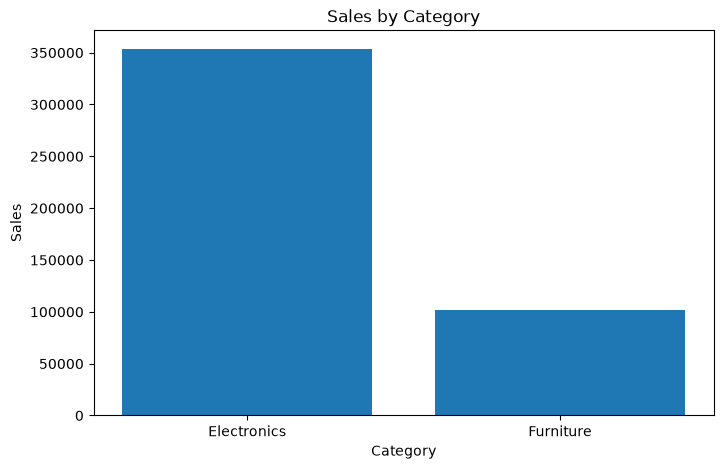

In [48]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

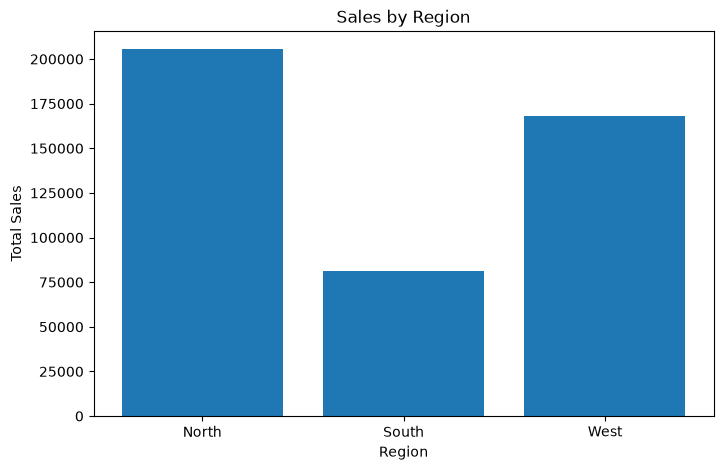

In [49]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(region_sales.index, region_sales.values)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

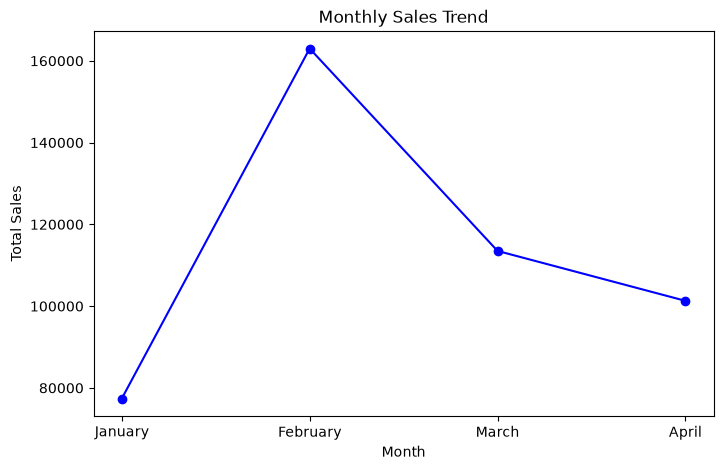

In [57]:
monthly_sales = df.groupby("Month")["Sales"].sum()

month_order = ["January", "February", "March", "April"]
monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values,marker='o', linestyle='-', color='b')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

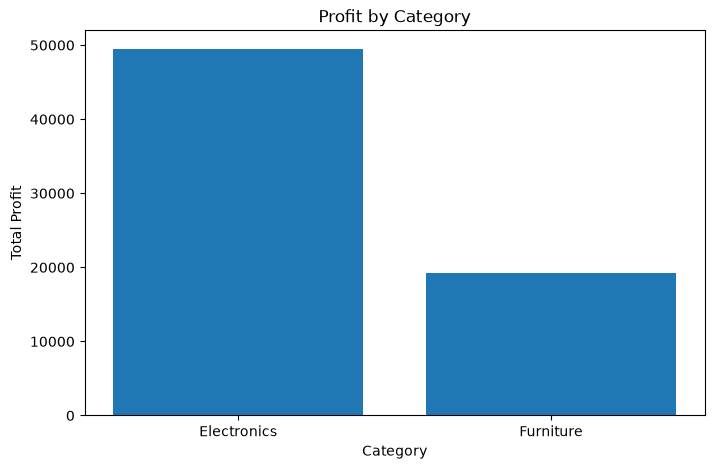

In [58]:
category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
plt.bar(category_profit.index, category_profit.values)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

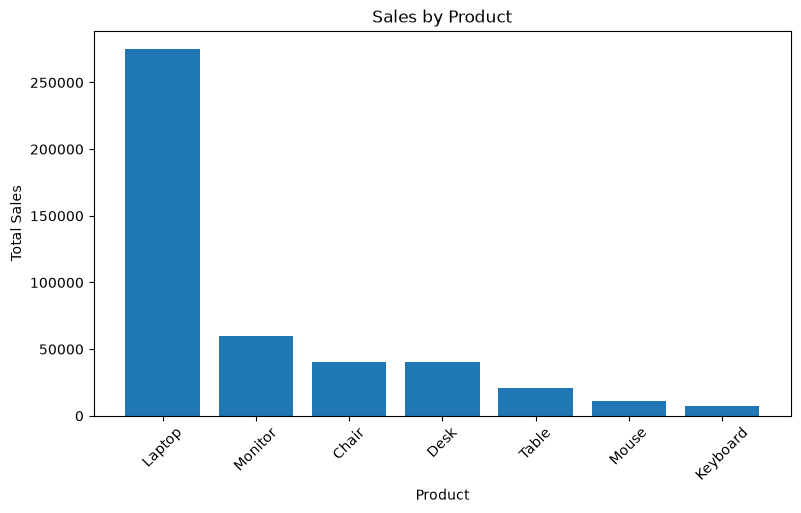

In [59]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
plt.bar(product_sales.index, product_sales.values)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

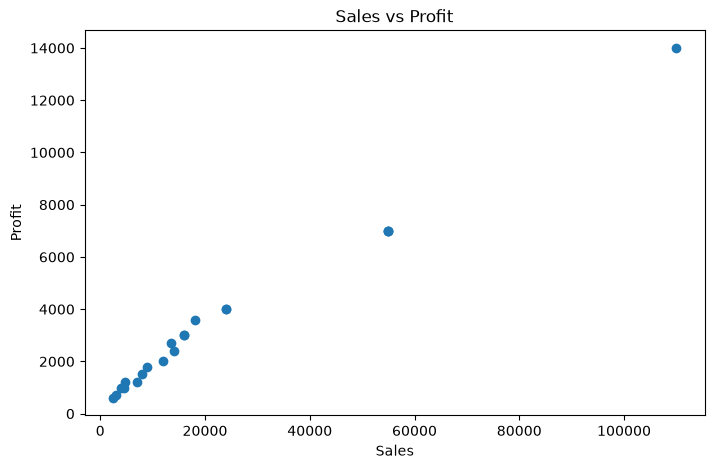

In [60]:
plt.figure(figsize=(8,5))
plt.scatter(df["Sales"], df["Profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

## Visualization Findings & Business Insights

### Sales by Category
- Electronics generated higher sales than Furniture.
- Electronics is the stronger category in terms of overall sales performance.

### Sales by Region
- North region recorded the highest sales.
- South region recorded the lowest sales among the three regions.

### Monthly Sales Trend
- February recorded the highest monthly sales.
- January recorded the lowest monthly sales.
- Sales increased significantly in February and then decreased in March and April.

### Profit by Category
- Electronics generated higher profit than Furniture.
- The Electronics category is the main contributor to overall profit.

### Sales by Product
- Laptop generated the highest sales among all products.
- Keyboard generated the lowest sales.
- High-value products contributed significantly to total revenue.

### Sales vs Profit
- Sales and Profit show a very strong positive relationship.
- The correlation between Sales and Profit is approximately 0.995.
- This indicates that higher sales are generally associated with higher profit in this dataset.

# Final Conclusion

The analysis of the retail sales dataset helped identify important patterns in sales and profitability.

Key findings:
- Electronics is the strongest category in terms of sales and profit.
- North region generated the highest sales.
- February recorded the highest monthly sales and profit.
- Laptop generated the highest product-wise sales.
- All orders in the dataset were profitable.
- Sales and Profit have a very strong positive relationship.

The visualizations make these business patterns easier to understand and support data-driven decision making.